<a href="https://colab.research.google.com/github/miku390219/ml-practice/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 決定木の実装

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import export_graphviz
import graphviz

In [2]:
data = {
    '色': ['赤', '赤', '赤', '黄', '黄', '黄', '赤', '赤', '黄', '黄', '赤', '黄', '黄', '赤', '赤', '黄', '黄', '赤', '黄', '赤', '黄', '赤', '黄', '赤', '黄', '赤', '黄', '赤', '黄'],
    'サイズ': ['大', '大', '小', '大', '小', '小', '小', '大', '小', '大', '大', '大', '小', '小', '大', '小', '大', '小', '大', '大', '小', '小', '大', '大', '小', '大', '大', '小', '大'],
    'フルーツ': ['リンゴ', 'リンゴ', 'チェリー', 'バナナ', 'チェリー', 'バナナ', 'チェリー', 'リンゴ', 'バナナ', 'リンゴ', 'チェリー', 'バナナ', 'リンゴ', 'チェリー', 'バナナ', 'リンゴ', 'チェリー', 'リンゴ', 'バナナ', 'リンゴ', 'チェリー', 'バナナ', 'リンゴ', 'チェリー', 'バナナ', 'リンゴ', 'バナナ', 'チェリー', 'リンゴ']
}

In [3]:
dataset = pd.DataFrame(data)
print(dataset)

    色 サイズ  フルーツ
0   赤   大   リンゴ
1   赤   大   リンゴ
2   赤   小  チェリー
3   黄   大   バナナ
4   黄   小  チェリー
5   黄   小   バナナ
6   赤   小  チェリー
7   赤   大   リンゴ
8   黄   小   バナナ
9   黄   大   リンゴ
10  赤   大  チェリー
11  黄   大   バナナ
12  黄   小   リンゴ
13  赤   小  チェリー
14  赤   大   バナナ
15  黄   小   リンゴ
16  黄   大  チェリー
17  赤   小   リンゴ
18  黄   大   バナナ
19  赤   大   リンゴ
20  黄   小  チェリー
21  赤   小   バナナ
22  黄   大   リンゴ
23  赤   大  チェリー
24  黄   小   バナナ
25  赤   大   リンゴ
26  黄   大   バナナ
27  赤   小  チェリー
28  黄   大   リンゴ


In [6]:
#特徴量とラベルに分割
X = pd.get_dummies(dataset.iloc[:, :-1])
y = dataset.iloc[:, -1].values

In [8]:
#データ分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [9]:
#決定機モデルのトレーニング
classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [10]:
#テストデータで予測
y_pred = classifier.predict(X_test)

In [15]:
#混同行列の作成
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2 1 1]
 [0 1 0]
 [0 0 1]]


In [16]:
#精度の計算
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy: .2f}')

Accuracy:  0.67


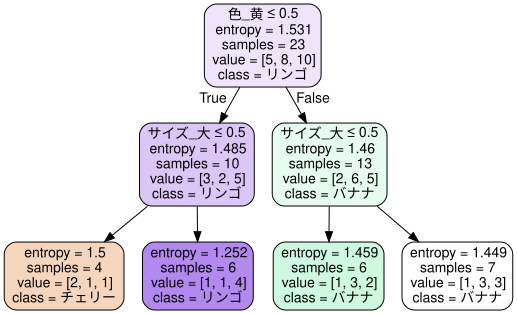

In [17]:
# 決定木の可視化
dot_data = export_graphviz(classifier, out_file=None, feature_names=X.columns, class_names=classifier.classes_, filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")

# グラフを表示
graph